In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:
#load the dataset
df_patient = pd.read_csv('simulation_patient_timestamps.csv')
df_patient



,Patient ID,Type,Arrival,Reporting Queue,Reporting Start,Reporting End,Completed
0,Pap-000001,pap_smear,2026-05-01 09:00,2026-05-01 10:40,2026-05-01 10:40,2026-05-01 10:48,Yes
1,Pap-000002,pap_smear,2026-05-01 09:45,2026-05-01 10:40,2026-05-01 10:40,2026-05-01 11:20,Yes
2,Pap-000003,pap_smear,2026-05-01 11:51,2026-05-01 13:14,2026-05-01 13:14,2026-05-01 14:10,Yes
3,Pap-000004,pap_smear,2026-05-01 12:14,2026-05-01 13:14,2026-05-01 13:14,2026-05-01 13:30,Yes
4,Pap-000005,pap_smear,2026-05-01 12:49,2026-05-01 13:49,2026-05-01 13:49,2026-05-01 14:30,Yes
...,...,...,...,...,...,...,...
10010,NonPap-007802,non_pap_smear,2027-04-30 14:07,2027-04-30 17:10,NaN,NaN,No
10011,NonPap-007803,non_pap_smear,2027-04-30 14:27,2027-04-30 17:45,NaN,NaN,No
10012,NonPap-007804,non_pap_smear,2027-04-30 14:28,2027-04-30 17:45,NaN,NaN,No
10013,NonPap-007805,non_pap_smear,2027-04-30 15:51,2027-04-30 18:20,NaN,NaN,No


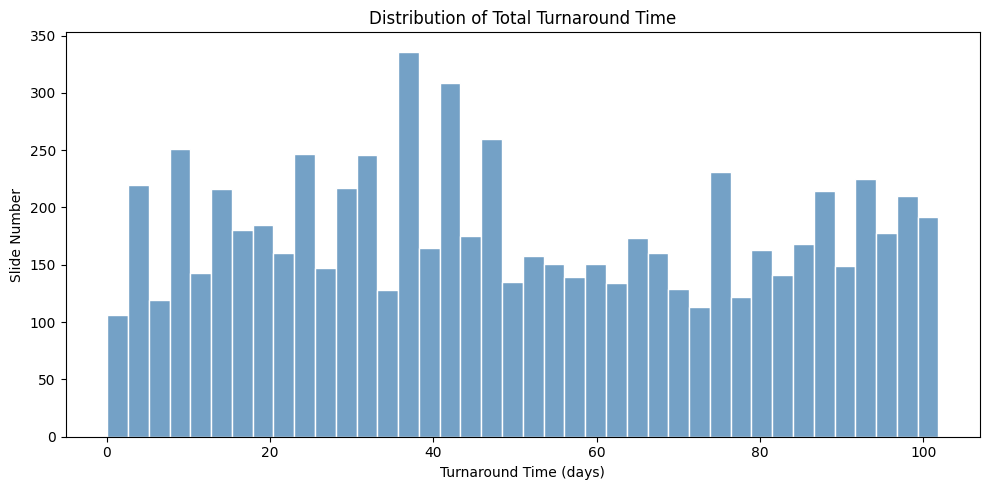

In [10]:
# Calculating turnaround time
if {'result_time', 'test_time'}.issubset(df_patient.columns):
    df_patient['turnaround_time'] = pd.to_datetime(df_patient['result_time']) - pd.to_datetime(df_patient['test_time'])

df_patient['total_turnaround_time'] = pd.to_datetime(df_patient['Reporting End']) - pd.to_datetime(df_patient['Arrival'])
df_patient['total_turnaround_days'] = df_patient['total_turnaround_time'].dt.total_seconds() / (24 * 3600)

plot_df = df_patient.dropna(subset=['total_turnaround_days']).copy()

plt.figure(figsize=(10, 5))
sns.histplot(plot_df['total_turnaround_days'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Turnaround Time (days)')
plt.ylabel('Slide Number')
plt.title('Distribution of Total Turnaround Time')
plt.tight_layout()
plt.show()